ARBOLES DE DECISIÓN


In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree

In [ ]:
mydata = pd.read_csv("drug200.csv", delimiter = ",")
X = mydata[['Age','Sex','BP','Cholesterol','Na_to_K']].values

In [ ]:
from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1])


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3])

y = mydata["Drug"]
y[0:5]

ValueError: ignored

In [ ]:
from sklearn.model_selection import train_test_split

trainx, testx, trainy, testy = train_test_split(X,y, test_size=0.3)

In [ ]:
## Construcción del modelo

drugTree = DecisionTreeClassifier(criterion = "entropy", max_depth=3)
drugTree.fit(trainx,trainy)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [ ]:
predicciones = drugTree.predict(testx)

In [ ]:
print(predicciones[0:20])
print(testy[0:20])

['drugY' 'drugX' 'drugY' 'drugY' 'drugX' 'drugY' 'drugY' 'drugX' 'drugC'
 'drugY' 'drugA' 'drugA' 'drugY' 'drugX' 'drugA' 'drugY' 'drugY' 'drugX'
 'drugX' 'drugX']
21     drugY
81     drugX
15     drugY
115    drugY
116    drugX
13     drugY
154    drugY
152    drugX
193    drugC
179    drugY
110    drugA
66     drugA
97     drugY
111    drugX
169    drugA
178    drugY
183    drugY
35     drugX
86     drugX
114    drugX
Name: Drug, dtype: object


In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

metrics.accuracy_score(testy, predicciones)

0.9

[Text(0.625, 0.875, 'x[4] <= 14.839\nentropy = 1.977\nsamples = 140\nvalue = [16, 13, 10, 38, 63]'),
 Text(0.5, 0.625, 'x[2] <= 0.5\nentropy = 1.79\nsamples = 77\nvalue = [16, 13, 10, 38, 0]'),
 Text(0.25, 0.375, 'x[0] <= 50.0\nentropy = 0.992\nsamples = 29\nvalue = [16, 13, 0, 0, 0]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 16\nvalue = [16, 0, 0, 0, 0]'),
 Text(0.375, 0.125, 'entropy = 0.0\nsamples = 13\nvalue = [0, 13, 0, 0, 0]'),
 Text(0.75, 0.375, 'x[3] <= 0.5\nentropy = 0.738\nsamples = 48\nvalue = [0, 0, 10, 38, 0]'),
 Text(0.625, 0.125, 'entropy = 0.98\nsamples = 24\nvalue = [0, 0, 10, 14, 0]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 24\nvalue = [0, 0, 0, 24, 0]'),
 Text(0.75, 0.625, 'entropy = 0.0\nsamples = 63\nvalue = [0, 0, 0, 0, 63]')]

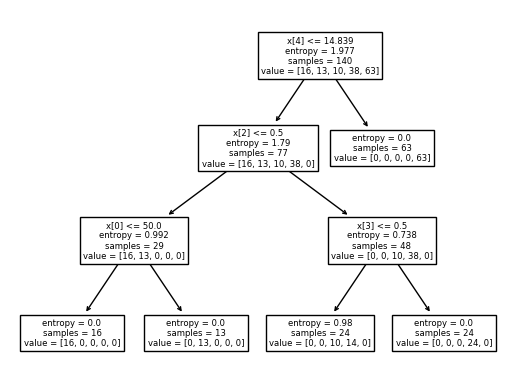

In [ ]:
tree.plot_tree(drugTree)

K-MEDIAS

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

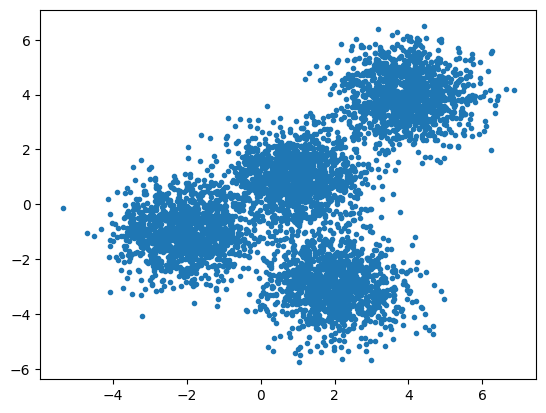

In [ ]:
np.random.seed(0)
X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)
plt.scatter(X[:, 0], X[:, 1], marker='.')


In [ ]:
k_means = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)
k_means.fit(X)
k_means_labels = k_means.labels_
k_means_labels
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

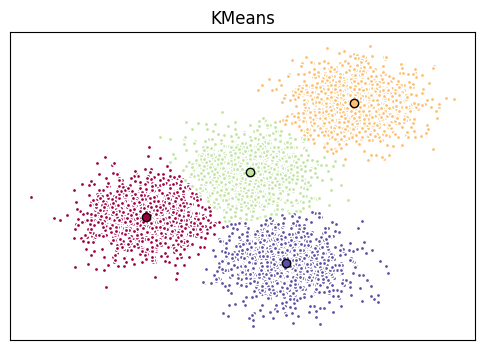

In [ ]:
# Initialize the plot with the specified dimensions.
fig = plt.figure(figsize=(6, 4))

# Colors uses a color map, which will produce an array of colors based on
# the number of labels there are. We use set(k_means_labels) to get the
# unique labels.
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means_labels))))

# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the data points and centroids.
# k will range from 0-3, which will match the possible clusters that each
# data point is in.
for k, col in zip(range(len([[4,4], [-2, -1], [2, -3], [1, 1]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means_labels == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means_cluster_centers[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

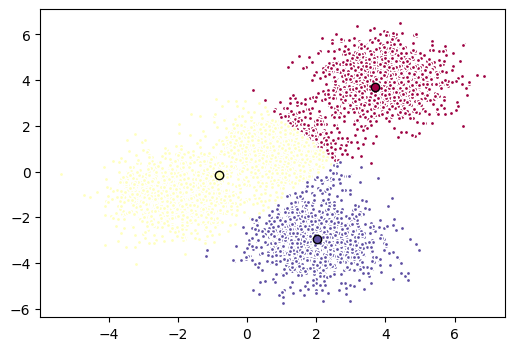

In [ ]:
k_means3 = KMeans(init = "k-means++", n_clusters = 3, n_init = 12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()